# Triasole in Lake Geneva

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
%matplotlib widget 

### Profile of triasole from SHL2

Text(0.5, 0, 'Conc [$\\mu$g/l]')

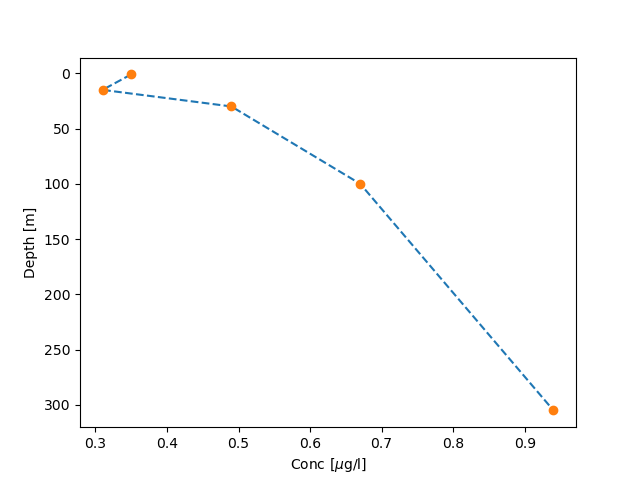

In [5]:
depth=np.array([1,15,30,100,305])
conc=np.array([0.35,0.31,0.49,0.67,0.94])
depth_interp=np.arange(1,305,1)
conc_interp=np.interp(depth_interp,depth,conc)

plt.figure()
plt.plot(conc_interp,depth_interp,'--')
plt.plot(conc,depth,'o')
plt.gca().invert_yaxis()
plt.gca().set_ylabel("Depth [m]")
plt.gca().set_xlabel("Conc [$\mu$g/l]")

In [6]:
plt.savefig("profile",dpi=400)

Computes concentration in epilimnion and hypolimnion:

In [7]:
depth_therm=150
Cepi_avg=np.mean(conc[depth<depth_therm])
Chypo_avg=np.mean(conc[depth>depth_therm])
Cepi_interp_avg=np.mean(conc_interp[depth_interp<depth_therm])
Chypo_interp_avg=np.mean(conc_interp[depth_interp>depth_therm])
Rconc=Cepi_avg/Chypo_avg
Dconc=Chypo_avg-Cepi_avg
Rconc_interp=Cepi_interp_avg/Chypo_interp_avg # Assumes linear profile
Dconc_interp=Chypo_interp_avg-Cepi_interp_avg
Cmean=np.mean(conc_interp)
print("Cepi/Chypo = {:.3f}, Chypo-Cepi={:.3f}".format(Rconc,Dconc))
print("Cepi/Chypo interp = {:.3f},Chypo-Cepi interp={:.3f}".format(Rconc_interp,Dconc_interp))

Cepi/Chypo = 0.484, Chypo-Cepi=0.485
Cepi/Chypo interp = 0.690,Chypo-Cepi interp=0.260


### Concentration time series from known C0 and Cin

Assumptions: 
- same residence time between epi and hypo
- $C_0<<C_{in}$

In [8]:
C0=0 # C0<<Cin
Cin=1 # Slightly higher than bottom concentration
t_ratio=np.arange(0,10,1/100) # t/tau

In [9]:
def Cepi(t_ratio,C0,Cin): # For same residence time between epi and hypo and same initial C0
    return Cin+(C0-Cin)*np.exp(-t_ratio)*(1+t_ratio)

In [12]:
def Cepi_nonmixed(t_ratio,C0e,C0h,Cin): # For same residence time between epi and hypo and different C0
    return Cin+np.exp(-t_ratio)*(C0e-Cin+t_ratio*(C0h-Cin))

In [13]:
def Chypo(t_ratio,C0,Cin): 
    return Cin+(C0-Cin)*np.exp(-t_ratio)

In [14]:
def Cepi_nondim(t_ratio): # (Cepi-C0)/(Cin-C0)
    return 1-t_ratio*np.exp(-t_ratio)-np.exp(-t_ratio)

In [15]:
def Chypo_nondim(t_ratio): # (Chypo-C0)/(Cin-C0)
    return 1-np.exp(-t_ratio)

In [16]:
def diff_conc(t_ratio,C0,Cin): # Difference Chypo-Cepi
    return (Cin-C0)*t_ratio*np.exp(-t_ratio)

In [17]:
def equation_conc_ratio(t_ratio,Rconc,C0,Cin): # Equation giving the dimensionless time t/tau for which the concentration ratio is Rconc
    return Cepi(t_ratio,C0,Cin)/Chypo(t_ratio,C0,Cin)-Rconc # To be solved numerically to minimize it (must be equal to zero)

In [18]:
def equation_conc_nondim_ratio(t_ratio,Rconc): # Equation giving the dimensionless time t/tau for which the nondim concentration ratio is Rconc
    return Cepi_nondim(t_ratio)/Chypo_nondim(t_ratio)-Rconc # To be solved numerically to minimize it (must be equal to zero)

In [19]:
def equation_conc_diff(t_ratio,Dconc,C0,Cin): # Equation giving the dimensionless time t/tau for which the concentration ratio is Rconc
    return diff_conc(t_ratio,C0,Cin)-Dconc # To be solved numerically to minimize it (must be equal to zero)

In [20]:
def equation_conc_nondim_diff(t_ratio,Dconc): # Equation giving the dimensionless time t/tau for which the nondim concentration diff (Chypo-Cepi)/(Cin-C0) is Dconc
    return Chypo_nondim(t_ratio)-Cepi_nondim(t_ratio)-Dconc # To be solved numerically to minimize it (must be equal to zero)

Solve for dimensionless time where concentration ratio $C_{epi}/C_{hypo}$ reaches observed ratio:

In [21]:
t_ratio_sol=fsolve(equation_conc_ratio, x0=1, args=(Rconc_interp,C0,Cin))

Same using normalized concentration ratio $(C_{epi}-C_0)/(C_{hypo}-C_0)$:

In [22]:
Rconc_C0=(Cepi_interp_avg-C0)/(Chypo_interp_avg-C0)
t_ratio_sol2=fsolve(equation_conc_nondim_ratio, x0=1, args=(Rconc_C0))

Solve for dimensionless time where concentration difference reaches observed difference:

In [23]:
t_diff_sol=fsolve(equation_conc_diff, x0=1, args=(Dconc_interp,C0,Cin))

### Plot concentration series , ratio and differences

In [24]:
Cepi_series=Cepi(t_ratio,C0,Cin)
Chypo_series=Chypo(t_ratio,C0,Cin)

Plot concentration series & ratio

Text(0.5, 0.98, '$C_0$=0, $C_{in}$=1')

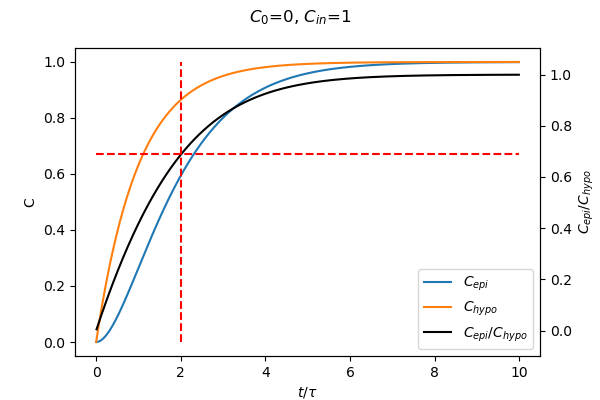

In [25]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_series,'-')
p2,=ax.plot(t_ratio,Chypo_series,'-')
ax_right = ax.twinx()
p3,=ax_right.plot(t_ratio[Chypo_series>0],Cepi_series[Chypo_series>0]/Chypo_series[Chypo_series>0],'k-')
p4,=ax_right.plot(t_ratio[np.array([0,-1])],Rconc_interp*np.full((2,),1),'r--')
ylimval=ax_right.get_ylim()
p5,=ax_right.plot(t_ratio_sol*np.full((2,),1),ylimval,'r--')
ax.legend([p1,p2,p3],["$C_{epi}$","$C_{hypo}$","$C_{epi}/C_{hypo}$"])
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("C")
ax_right.set_ylabel("$C_{epi}/C_{hypo}$")
fig.suptitle("$C_0$={}, $C_{{in}}$={}".format(C0,Cin))

Plot concentration series & difference

Text(0.5, 0.98, '$C_0$=0, $C_{in}$=1')

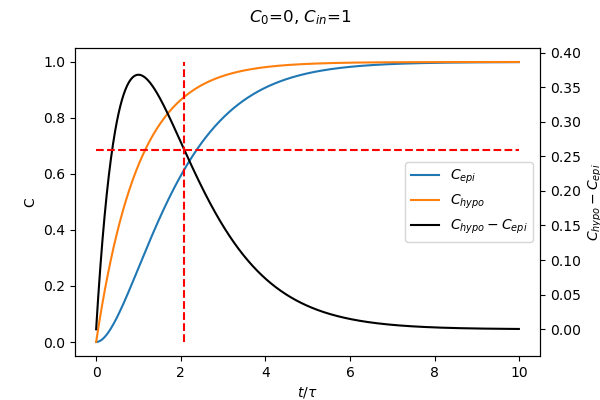

In [26]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_series,'-')
p2,=ax.plot(t_ratio,Chypo_series,'-')
ax_right = ax.twinx()
p3,=ax_right.plot(t_ratio,Chypo_series-Cepi_series,'k-')
p4,=ax_right.plot(t_ratio[np.array([0,-1])],Dconc_interp*np.full((2,),1),'r--')
ylimval=ax_right.get_ylim()
p5,=ax_right.plot(t_diff_sol*np.full((2,),1),ylimval,'r--')
ax.legend([p1,p2,p3],["$C_{epi}$","$C_{hypo}$","$C_{hypo}-C_{epi}$"],loc="center right")
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("C")
ax_right.set_ylabel("$C_{hypo}-C_{epi}$")
fig.suptitle("$C_0$={}, $C_{{in}}$={}".format(C0,Cin))

### Plot dimensionless concentration series , ratio and differences (all independent of C0 and Cin)

Dimensionless values at a certain time:

In [27]:
tau_val=5.5
tf_val=13 # Since last mixing
Cepi_val=Cepi_nondim(tf_val/tau_val) # (Cepi-C0)/(Cin-C0)
Chypo_val=Chypo_nondim(tf_val/tau_val) # (Chypo-C0)/(Cin-C0)
Dconc_val=Chypo_nondim(tf_val/tau_val)-Cepi_nondim(tf_val/tau_val) # (Chypo-Cepi)/(Cin-C0)
Rconc_val=Cepi_nondim(tf_val/tau_val)/Chypo_nondim(tf_val/tau_val) # (Cepi-C0)/(Chypo-C0)

In [28]:
tf_val/tau_val

2.3636363636363638

In [29]:
Dconc_val

0.22236500104017454

In [30]:
Rconc_val

0.7545430197967334

Ratio

Text(0, 0.5, '$R=(C_{epi}-C_0)/(C_{hypo}-C_0)$')

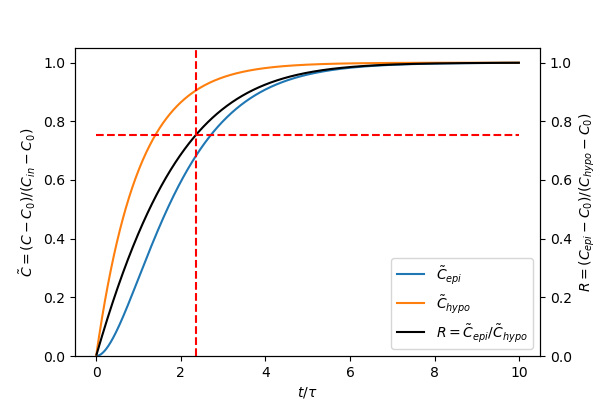

In [31]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_nondim(t_ratio),'-')
p2,=ax.plot(t_ratio,Chypo_nondim(t_ratio),'-')
ax.set_ylim(0,1.05)
ax_right = ax.twinx()
p3,=ax_right.plot(t_ratio[Chypo_nondim(t_ratio)>0],Cepi_nondim(t_ratio)[Chypo_nondim(t_ratio)>0]/Chypo_nondim(t_ratio)[Chypo_nondim(t_ratio)>0],'k-')
ax_right.set_ylim(0,1.05)
ylimval=ax_right.get_ylim()
p4,=ax_right.plot(tf_val/tau_val*np.full((2,),1),ylimval,'r--')
p5,=ax_right.plot(t_ratio[np.array([0,-1])],Rconc_val*np.full((2,),1),'r--')
ax.legend([p1,p2,p3],["$\\tilde{C}_{epi}$","$\\tilde{C}_{hypo}$","$R=\\tilde{C}_{epi}/\\tilde{C}_{hypo}$"])
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("$\\tilde{C}=(C-C_0)/(C_{in}-C_0)$")
ax_right.set_ylabel("$R=(C_{epi}-C_0)/(C_{hypo}-C_0)$")

In [32]:
fig.savefig("Nondim_ratio",dpi=400)

Difference

Text(0, 0.5, '$D=(C_{hypo}-C_{epi})/(C_{in}-C_0)$')

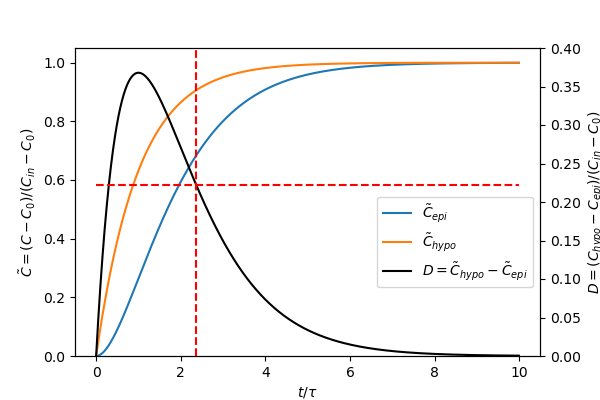

In [33]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_nondim(t_ratio),'-')
p2,=ax.plot(t_ratio,Chypo_nondim(t_ratio),'-')
ax.set_ylim(0,1.05)
ax_right = ax.twinx()
p3,=ax_right.plot(t_ratio,Chypo_nondim(t_ratio)-Cepi_nondim(t_ratio),'k-')
ax_right.set_ylim(0,0.4)
ylimval=ax_right.get_ylim()
p4,=ax_right.plot(tf_val/tau_val*np.full((2,),1),ylimval,'r--')
p5,=ax_right.plot(t_ratio[np.array([0,-1])],Dconc_val*np.full((2,),1),'r--')
lg=ax.legend([p1,p2,p3],["$\\tilde{C}_{epi}$","$\\tilde{C}_{hypo}$","$D=\\tilde{C}_{hypo}-\\tilde{C}_{epi}$"],loc="lower right",bbox_to_anchor=(1,0.2))
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("$\\tilde{C}=(C-C_0)/(C_{in}-C_0)$")
ax_right.set_ylabel("$D=(C_{hypo}-C_{epi})/(C_{in}-C_0)$")

In [34]:
fig.savefig("Nondim_difference",dpi=400)

### Varying Cepi and Chypo after a certain period

In [35]:
tau=5.5
tf=13

In [36]:
def Cin_solution(Cepi,Chypo,t_ratio):
    return Chypo+(Chypo-Cepi)/t_ratio

In [37]:
def C0_solution(Cepi,Chypo,t_ratio):
    return Chypo+(Chypo-Cepi)/t_ratio*(1-np.exp(t_ratio))

In [38]:
Cepi_array=np.arange(0.4,0.7,0.01)
Chypo_array=np.arange(0.6,0.9,0.01)

In [39]:
Cin_array=np.full((len(Cepi_array),len(Chypo_array)),np.nan)
C0_array=np.full((len(Cepi_array),len(Chypo_array)),np.nan)

In [40]:
for kepi in range(len(Cepi_array)):
    for khypo in range(len(Chypo_array)):
        Cin_sol=Cin_solution(Cepi_array[kepi],Chypo_array[khypo],tf/tau)
        C0_sol=C0_solution(Cepi_array[kepi],Chypo_array[khypo],tf/tau)
        if (Cin_sol>0 and C0_sol>0) and Cin_sol>C0_sol:
            Cin_array[kepi,khypo]=Cin_sol
            C0_array[kepi,khypo]=C0_sol

In [41]:
ztherm_var=np.arange(20,300)
Cepi_var=np.full(ztherm_var.shape,np.nan)
Chypo_var=np.full(ztherm_var.shape,np.nan)
for k in range(len(ztherm_var)):
    Cepi_var[k]=np.mean(conc_interp[depth_interp<ztherm_var[k]])
    Chypo_var[k]=np.mean(conc_interp[depth_interp>ztherm_var[k]])

Text(0.5, 1.0, '$C_{in}$')

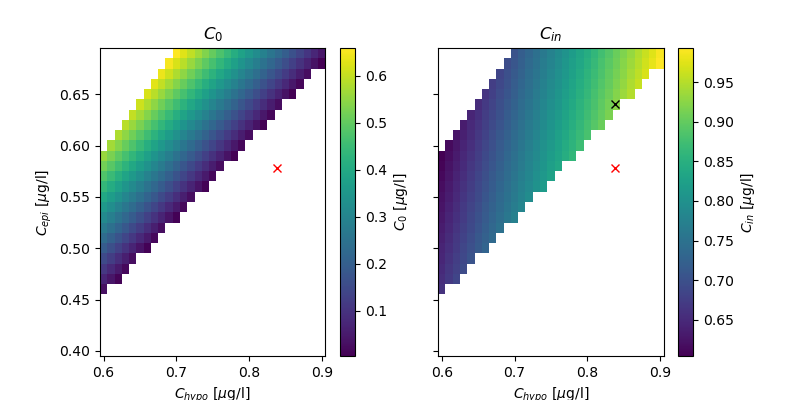

In [42]:
fig,ax=plt.subplots(1,2,figsize=(8,4),sharex=True,sharey=True)

pC0=ax[0].pcolormesh(Chypo_array,Cepi_array,C0_array)
fig.colorbar(pC0,label="$C_0$ [$\mu$g/l]")
xlimval=ax[0].get_xlim()
ax[0].plot(Chypo_var[ztherm_var==150],Cepi_var[ztherm_var==150],'rx')
#ax[0].plot(Chypo_var[ztherm_var==200],Cepi_var[ztherm_var==200],'kx')
#ax[0].plot(Chypo_var,Cepi_var,'-r')
ax[0].set_xlabel("$C_{hypo}$ [$\mu$g/l]")
ax[0].set_ylabel("$C_{epi}$ [$\mu$g/l]")
#ax[0].set_ylim(Cepi_array[0],Cepi_array[-1])
#ax[0].axis('equal')
ax[0].set_title("$C_0$")

pCin=ax[1].pcolormesh(Chypo_array,Cepi_array,Cin_array)
fig.colorbar(pCin,label="$C_{in}$ [$\mu$g/l]")
ax[1].plot(Chypo_var[ztherm_var==150],Cepi_var[ztherm_var==150],'rx')
ax[1].plot(Chypo_var[ztherm_var==150],0.64,'kx')
#ax[1].plot(Chypo_var[ztherm_var==200],Cepi_var[ztherm_var==200],'kx')
ax[1].set_xlabel("$C_{hypo}$ [$\mu$g/l]")
#ax[1].axis('equal')
ax[1].set_title("$C_{in}$")

In [43]:
fig.savefig("C0_Cin",dpi=400)

Plot different Cin=f(Chypo) curves for a few values of Cepi

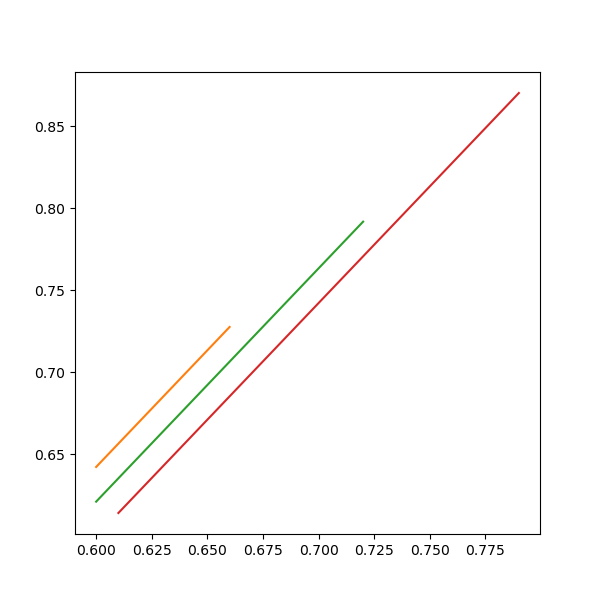

In [44]:
Cepi_val=np.array([0.45,0.5,0.55,0.6])

fig,ax=plt.subplots(1,1,figsize=(6,6))
for val in Cepi_val:
    ax.plot(Chypo_array,Cin_array[np.where(Cepi_array>=val)[0][0],:])


### Estimation of C0 and Cin from known concentrations after a certain period

In [45]:
tau=5.5
tf=13
Cef=0.64
Chf=Chypo_interp_avg
# Cef=Cepi_interp_avg
# Chf=Chypo_interp_avg
# Cef=Cepi_avg
# Chf=Chypo_avg

In [46]:
Cin_sol=Chf+(Chf-Cef)*tau/tf
Cin_sol2=Cin_solution(Cef,Chf,tf/tau)

In [47]:
C0_sol=Cin_sol+(Cef-Chf)/(tf/tau*np.exp(-tf/tau))
C0_sol2=C0_solution(Cef,Chf,tf/tau)

In [48]:
print("Cin={:.2f}, C0={:.2f}".format(Cin_sol,C0_sol))

Cin=0.92, C0=0.03


### Plot future concentrations if no input

In [63]:
C0e=0.58 # C0<<Cin
C0h=0.84
Cin=0
C_thresh=0.1
t_ratio=np.arange(0,10,1/100) # t/tau

In [64]:
Cepi_future=Cepi_nonmixed(t_ratio,C0e,C0h,Cin)
Chypo_future=Chypo(t_ratio,C0h,Cin)
t_ratio_thresh=t_ratio[np.where(Cepi_future<C_thresh)[0][0]]
print("Time to reach threshold: t/tau={}".format(t_ratio_thresh))

Time to reach threshold: t/tau=3.58


Text(0, 0.5, 'C [$\\mu$g/l]')

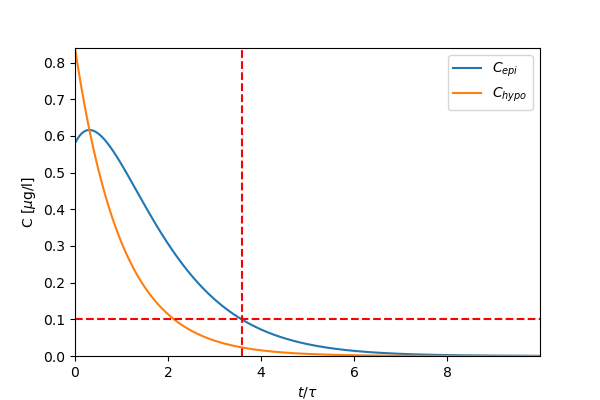

In [68]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
p1,=ax.plot(t_ratio,Cepi_future,'-')
p2,=ax.plot(t_ratio,Chypo_future,'-')
ax.plot(t_ratio[np.array([0,-1])],C_thresh*np.full((2,),1),'--r')
ax.set_ylim(0,C0h)
ax.set_xlim(t_ratio[0],t_ratio[-1])
ylimval=ax.get_ylim()
ax.plot(t_ratio_thresh*np.full((2,),1),ylimval,'--r')
ax.legend([p1,p2],["$C_{epi}$","$C_{hypo}$"])
ax.set_xlabel("$t/\\tau$")
ax.set_ylabel("C [$\mu$g/l]")

In [69]:
fig.savefig("conc_decrease.png",dpi=400)